### QED-C Application-Oriented Benchmarks - Hamiltonian Simulation with HamLib - Fidelity

The notebook contains specific examples for the HamLib-based Hamiltonian Simulation benchmark program.
Configure and run the cell below with the desired execution settings.
Then configure and run the remaining cell(s), each one a variation of this benchmark.

Note: This set of benchmarks exercises the fidelity-oriented assessment described in the paper: https://arxiv.org/abs/2409.06919

See other notebooks for new benchmarks that exercise the recently added "observables" capability.

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Benchmark application settings
app_args = dict(
    min_qubits = 4,
    max_qubits = 8,
    skip_qubits = 1,
    max_circuits = 3,
    num_shots = 1000,

    # method to generate commuting groups and compute observable values
    # Can be:  None, "simple", "1", "2", "N"
    group_method = "simple",

    # which API to use for execution, "qiskit" or "cudaq"
    api = "qiskit",
)

# # ==========================

# Execution settings - for QASM simulator backend - default
exec_args = dict(
    backend_id = "qasm_simulator",
    # backend_id = "statevector_simulator",
    
    exec_options = {},                                       # leave current noise setting unchanged
    # exec_options = { "noise_model": "default" },           # built-in depolarization model (the default)
    # exec_options = { "noise_model": None },                # no noise
    # exec_options = { "noise_model": my_noise_model },      # custom noise model object
)

In [3]:
# to override for specific backend, uncomment selected lines below

# # ==========================

# # Execution settings - for IBM backends - Cloud channel
# import os
# exec_args = dict(   
#     hub="", group="", project=os.environ.get("IBM_INSTANCE"),
#     exec_options = { "use_ibm_quantum_platform": False, "use_sessions": False},
#     backend_id = "ibm_fez",
# )
    
# # Execution settings - for IBM backends - IBM Quantum Platform
# exec_args = dict( 
#     hub="YOUR_HUB_NAME", group="YOUR_GROUP_NAME", project="YOUR_PROJECT_NAME",                      
#     exec_options = { "use_ibm_quantum_platform": True, "use_sessions": False},
#     backend_id = "ibm_brisbane",
# )

# # *** If using IBM Quantum hardware, run this once to authenticate
# from qiskit_ibm_runtime import QiskitRuntimeService
# QiskitRuntimeService.save_account('YOUR_API_TOKEN_HERE')  # only need to do this first time

# # ==========================

# # Execution settings - for IonQ backends
# # Be sure to set the QISKIT_IONQ_API_TOKEN environment variable
# from qiskit_ionq import IonQProvider  
# exec_args = dict(
#     provider_backend = IonQProvider().get_backend("ionq_qpu"),
#     backend_id="ionq_qpu",
# )

# # ==========================

# # Execution settings - for IQM backends
# from iqm.qiskit_iqm import IQMProvider
# exec_args = dict(
#     provider_backend = IQMProvider("https://YOUR_IQM_URL").get_backend(),
#     backend_id="IQM",
# )

# # ==========================

# # Execution settings - for BlueQubit backends (backend_id=CPU/QPU, device=cpu/qpu)
# import bluequbit, _common.executors.bluequbit_executor as bluequbit_executor
# exec_args = dict(
#     provider_backend = bluequbit.init(),
#     backend_id="BlueQubit-CPU",
#     exec_options = { "executor": bluequbit_executor.run, "device":"cpu" },
# )

# # ==========================
# # Custom optimization options

# # Example of pytket Transformer
# exec_args["exec_options"].update({ "optimization_level": 0, "layout_method":'sabre', "routing_method":'sabre', "transformer": tket_optimiser.high_optimisation })

# # Define a custom noise model to be used during execution
# import _common.custom.custom_qiskit_noise_model as custom_qiskit_noise_model
# exec_args["exec_options"].update({ "noise_model": custom_qiskit_noise_model.my_noise_model() })

In [4]:
# Initialize QED-C framework (loads API-specific modules)
# The imports below provide direct access to internal modules for debugging and tracing
import sys
sys.path.insert(1, "..")

from qedclib import initialize, metrics
initialize("qiskit", "hamlib", ["hamlib_simulation_kernel"])

import execute
execute.verbose = False
execute.verbose_time = False
#execute.noise = None

execute.verbose=True

# ... access to HamLib datasets
import hamlib._common.hamlib_utils as hamlib_utils
hamlib_utils.verbose = False

# ... for api-specific kernel functions (circuits)
import hamlib_simulation_kernel
hamlib_simulation_kernel.verbose = False

# ... for high-level HamLib simulation benchmark loop
import hamlib_simulation_benchmark
hamlib_simulation_benchmark.verbose = False

QED-C Quantum Circuit Execution Library (qedclib 2.0.6)


### Hamiltonian Simulation - Method 1 
This benchmark executes a Hamiltonian simulation using the Hamiltonian terms extracted from the specified HamLib dataset.
It computes the fidelity of Trotterized simulation using method 1, in which the resulting measurement distribution is compared against the distribution obtained from executing on an ideal classically implemented quantum simulator (noiseless). The difference in fidelity from 1.0 represents the effect of  noise in the backend target system.

Hamiltonian Simulation Benchmark Program - qiskit
... hamiltonian and params = condensedmatter/tfim/tfim, {'1D-grid': 'pbc', 'h': 2}
... group_method = simple
... execution starting at Jun 14, 2026 23:19:42 UTC
************
Executing [3] circuits with num_qubits = 4
... dataset_name = graph-1D-grid-pbc-qubitnodes_Lx-4_h-2
... number of terms in Hamiltonian = 8
************
Executing [3] circuits with num_qubits = 5
... dataset_name = graph-1D-grid-pbc-qubitnodes_Lx-5_h-2
... number of terms in Hamiltonian = 10
************
Executing [3] circuits with num_qubits = 6
... dataset_name = graph-1D-grid-pbc-qubitnodes_Lx-6_h-2
... number of terms in Hamiltonian = 12
************
Executing [3] circuits with num_qubits = 7
... dataset_name = graph-1D-grid-pbc-qubitnodes_Lx-7_h-2
... number of terms in Hamiltonian = 14
************
Executing [3] circuits with num_qubits = 8
... dataset_name = graph-1D-grid-pbc-qubitnodes_Lx-8_h-2
... number of terms in Hamiltonian = 16
************
Average Circ

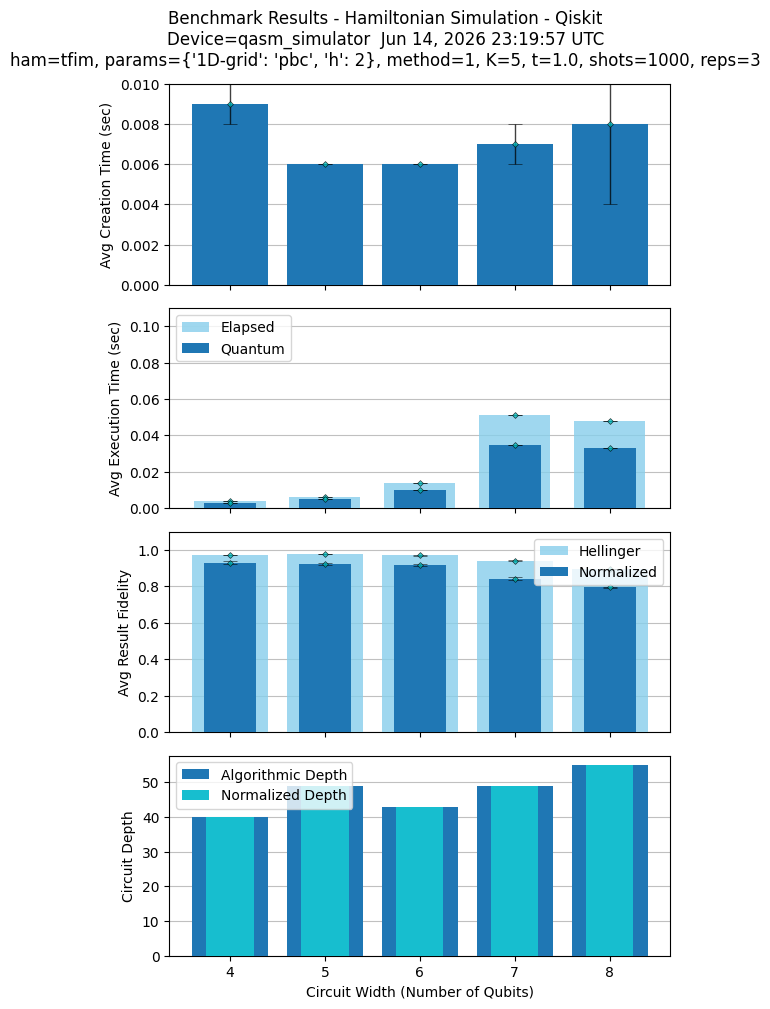

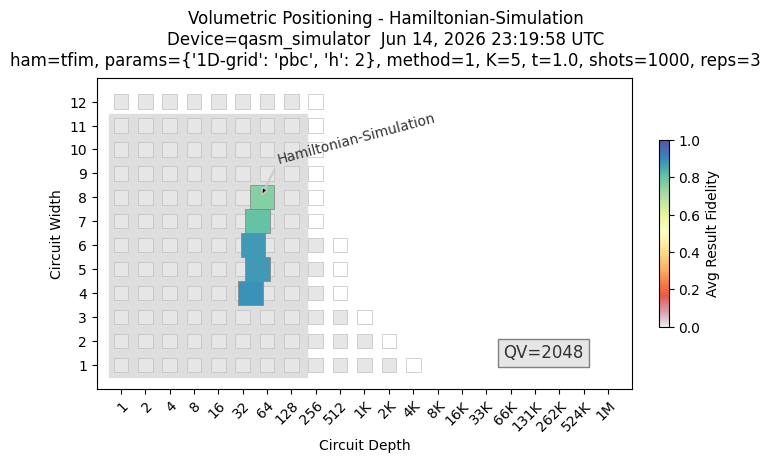

In [5]:
# Transverse Field Ising Model - 1D grid pbc h=2
hamiltonian_name = 'condensedmatter/tfim/tfim'
hamiltonian_params = { "1D-grid": "pbc", "h": 2 }
execute.verbose=True
hamlib_simulation_benchmark.run(
            hamiltonian=hamiltonian_name, hamiltonian_params=hamiltonian_params,
            method=1,
            **app_args, **exec_args)

### Hamiltonian Simulation - Method 2
This benchmark executes a Hamiltonian simulation using the Hamiltonian terms extracted from the specified HamLib dataset.
It computes the fidelity of Trotterized simulation using method 2, in which the resulting measurement distribution is compared against the distribution obtained from classically simulating the same Hamlitonian to the specified time. The difference in fidelity from 1.0 represents the effect of both noise in the backend target system and the accumulated Trotter error. 

Hamiltonian Simulation Benchmark Program - qiskit
... hamiltonian and params = condensedmatter/bosehubbard/BH_D-1_d-4, {'1D-grid': 'nonpbc', 'enc': 'gray', 'U': 10}
... group_method = simple
... execution starting at Jun 14, 2026 23:20:02 UTC
************
Executing [3] circuits with num_qubits = 4
... dataset_name = bh_graph-1D-grid-nonpbc-qubitnodes_Lx-2_U-10_enc-gray_d-4
... number of terms in Hamiltonian = 39
************
Executing [3] circuits with num_qubits = 6
... dataset_name = bh_graph-1D-grid-nonpbc-qubitnodes_Lx-3_U-10_enc-gray_d-4
... number of terms in Hamiltonian = 74
************
Executing [3] circuits with num_qubits = 8
... dataset_name = bh_graph-1D-grid-nonpbc-qubitnodes_Lx-4_U-10_enc-gray_d-4
... number of terms in Hamiltonian = 109
************
Average Circuit Algorithmic Depth, xi for the 4 qubit group = 1389, 0.335
Average Normalized Transpiled Depth, xi, 2q gates for the 4 qubit group = 794, 0.32, 365.0
Average Creation, Elapsed, Execution Time for the 4 qubit g

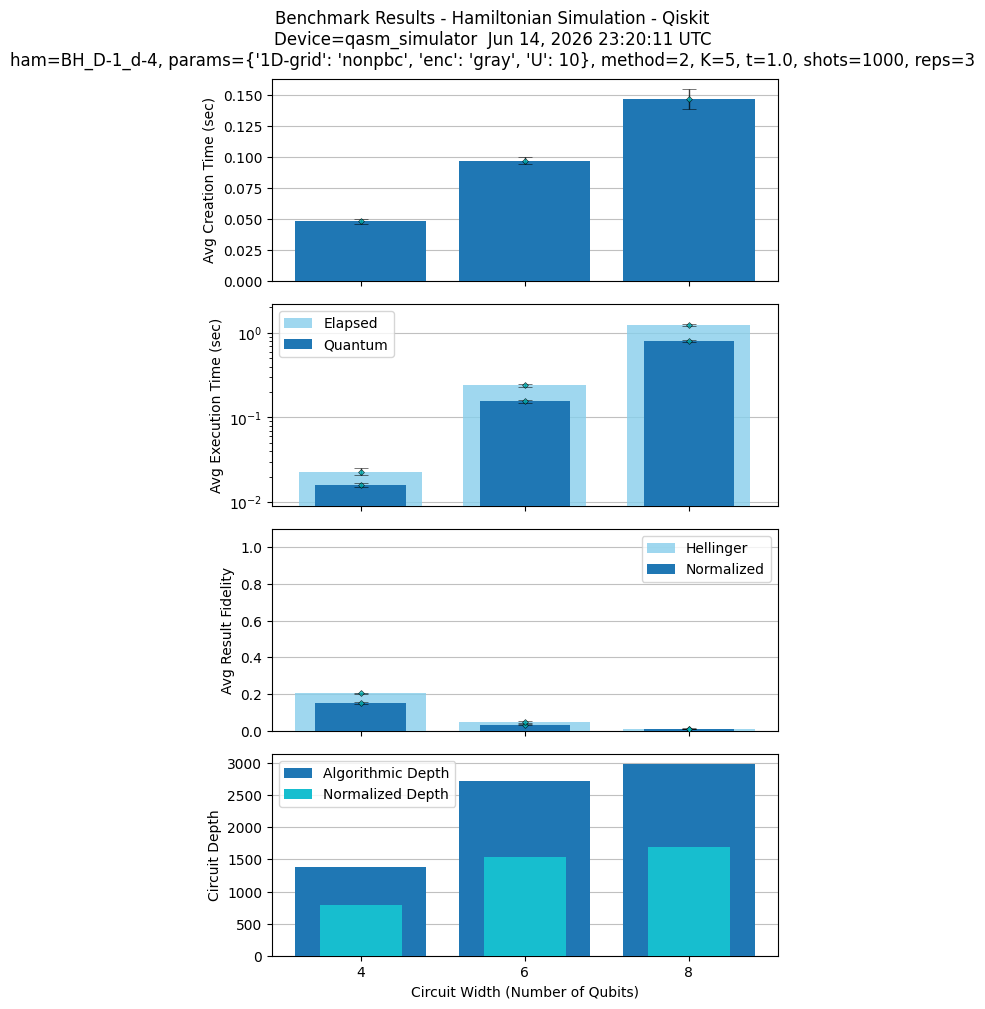

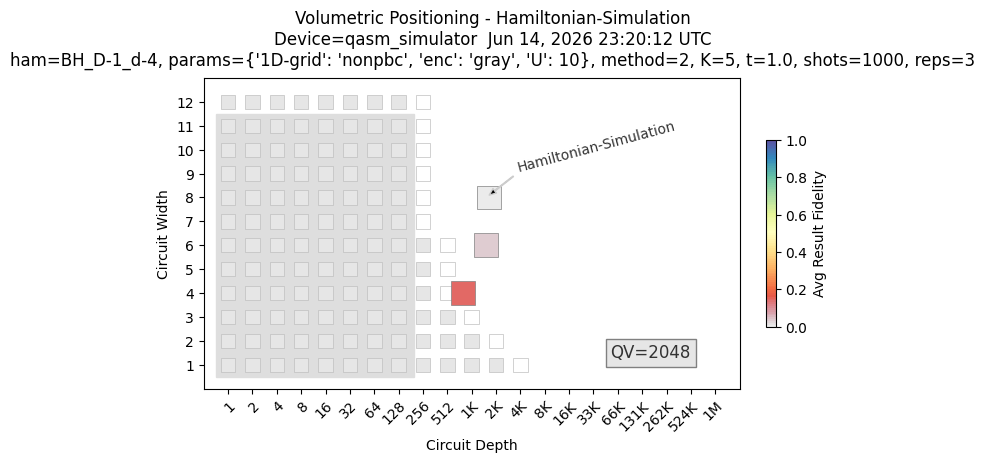

In [6]:
# Bose Hubbard 1D grid nonpbc d=4
hamiltonian_name = 'condensedmatter/bosehubbard/BH_D-1_d-4'
hamiltonian_params = { "1D-grid": "nonpbc", "enc": "gray", "U":10 }

hamlib_simulation_benchmark.run(
            hamiltonian=hamiltonian_name, hamiltonian_params=hamiltonian_params,
            method=2,
            **app_args, **exec_args)

### Hamiltonian Simulation - Method 3
This benchmark executes a Hamiltonian simulation using the Hamiltonian terms extracted from the specified HamLib dataset.
It computes the fidelity of Trotterized simulation using method 3, in which the Trotterized circuit is followed by the inverse of the Trotterized circuit and the resulting measurement distribution is compared against a distribution directly from the initial state. We take the square root of  fidelity obtained due to the doubling of the circuit depth. The difference in fidelity from 1.0 represents the effect of noise in the backend target system. This benchmark is scalable to larger numbers of qubits since it does not require a classical implementation of Hamiltonian simulation.

Hamiltonian Simulation Benchmark Program - qiskit
... hamiltonian and params = binaryoptimization/max3sat/random/random_max3sat-hams, {'ratio': '2', 'rinst': '02'}
... group_method = simple
... execution starting at Jun 14, 2026 23:20:14 UTC
************
Executing [3] circuits with num_qubits = 4
... dataset_name = max3sat_n-4_ratio-2_rinst-02
... number of terms in Hamiltonian = 12
************
Executing [3] circuits with num_qubits = 5
... dataset_name = max3sat_n-5_ratio-2_rinst-02
... number of terms in Hamiltonian = 17
************
Executing [3] circuits with num_qubits = 6
... dataset_name = max3sat_n-6_ratio-2_rinst-02
... number of terms in Hamiltonian = 22
************
Executing [3] circuits with num_qubits = 7
... dataset_name = max3sat_n-7_ratio-2_rinst-02
... number of terms in Hamiltonian = 32
************
Executing [3] circuits with num_qubits = 8
... dataset_name = max3sat_n-8_ratio-2_rinst-02
... number of terms in Hamiltonian = 38
************
Average Circuit Algorithm

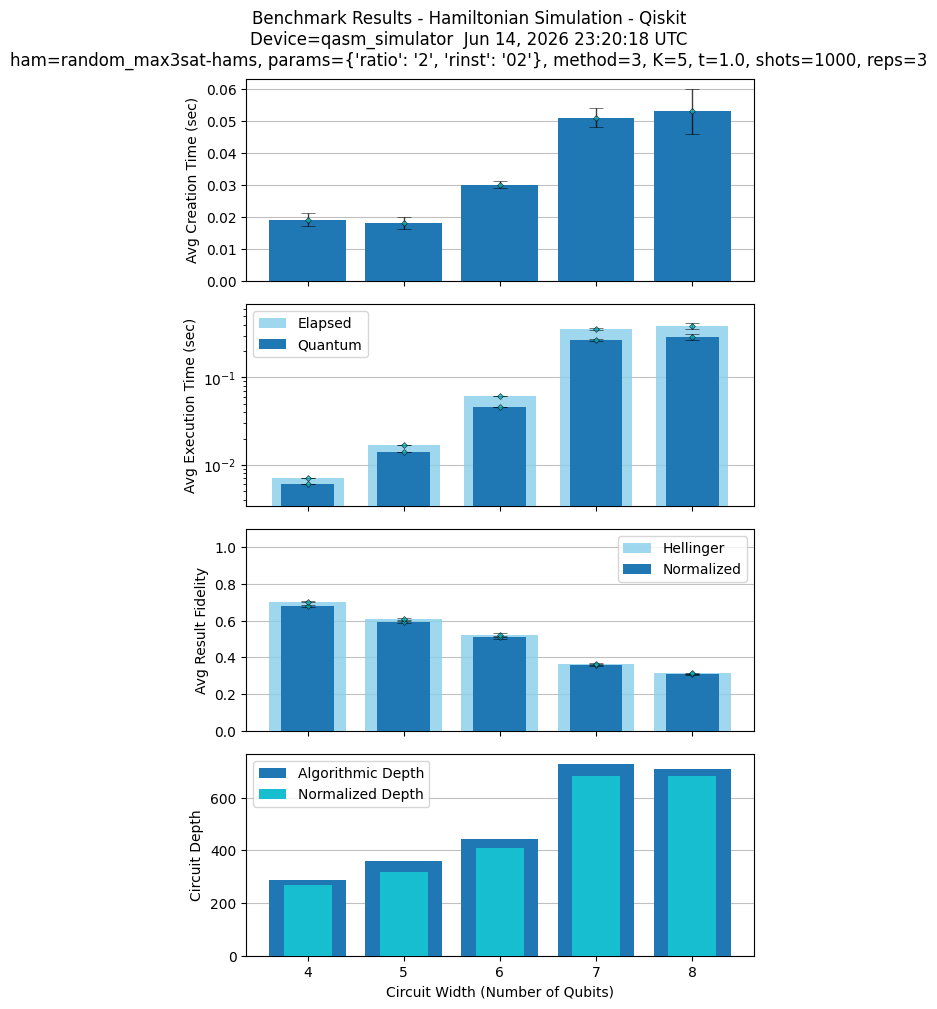

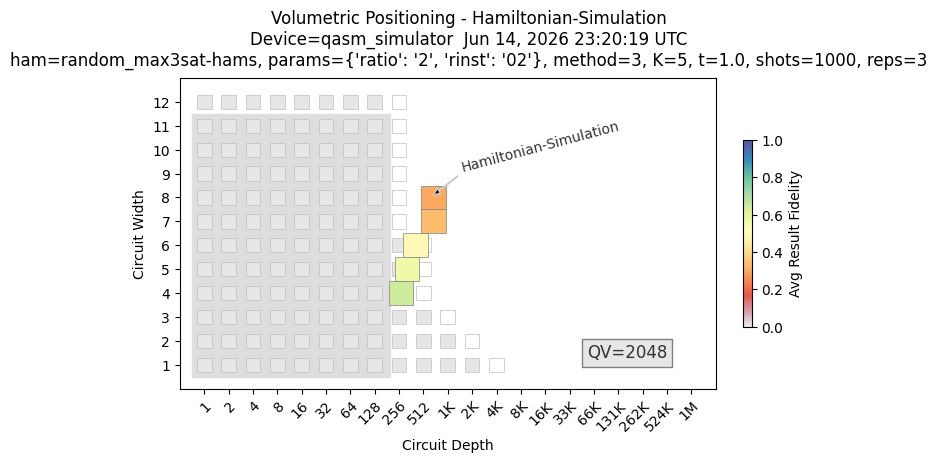

In [7]:
# Max3Sat - ratio 2 rinst 02
hamiltonian_name = 'binaryoptimization/max3sat/random/random_max3sat-hams'
hamiltonian_params = { "ratio": "2", "rinst": "02" }

hamlib_simulation_benchmark.run(
            hamiltonian=hamiltonian_name, hamiltonian_params=hamiltonian_params,
            method=3, do_sqrt_fidelity=True,
            **app_args, **exec_args)

### Hamiltonian Simulation - Method 3

Hamiltonian Simulation Benchmark Program - qiskit
... hamiltonian and params = chemistry/electronic/standard/H2, {'ham_BK': ''}
... group_method = simple
... execution starting at Jun 14, 2026 23:20:21 UTC
************
Executing [3] circuits with num_qubits = 4
... dataset_name = ham_BK-4
... number of terms in Hamiltonian = 15
************
Executing [3] circuits with num_qubits = 6
... dataset_name = ham_BK-6
... number of terms in Hamiltonian = 62
************
Executing [3] circuits with num_qubits = 8
... dataset_name = ham_BK-8
... number of terms in Hamiltonian = 185
************
Average Circuit Algorithmic Depth, xi for the 4 qubit group = 714, 0.488
Average Normalized Transpiled Depth, xi, 2q gates for the 4 qubit group = 505, 0.372, 260.0
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0.03, 0.016, 0.011 secs
Average Transpiling, Validating, Running Times for group 4 = 0.001, 0.001, 0.001 secs
Average Hellinger, Normalized Fidelity for the 4 qubit group = 0.6,

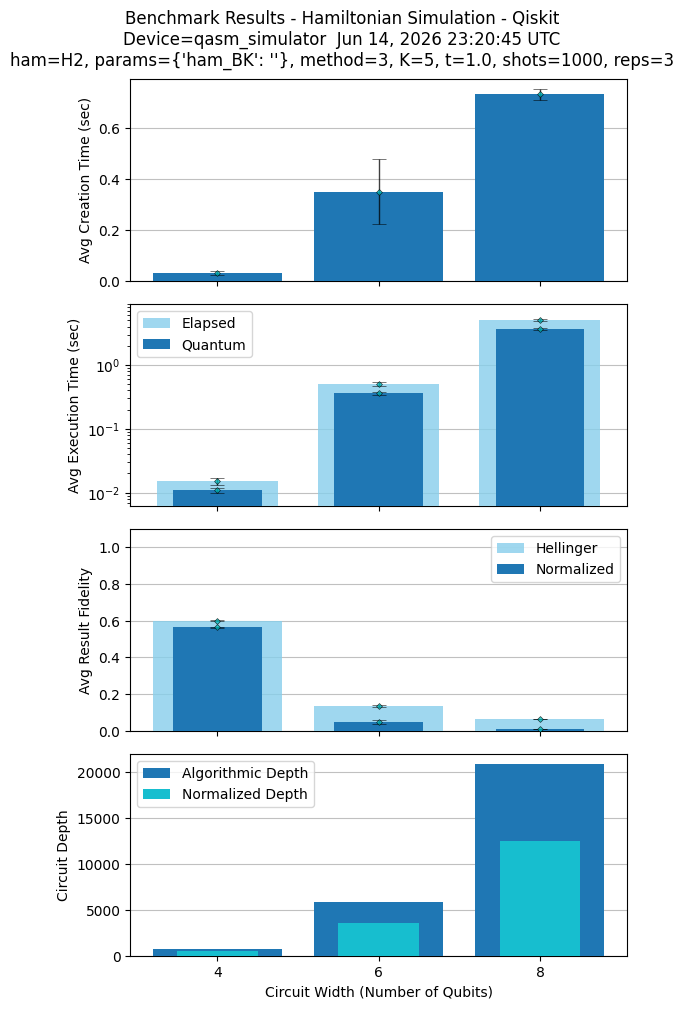

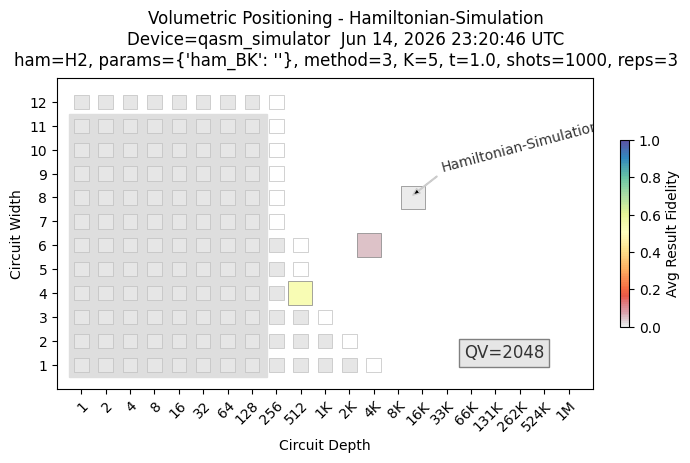

In [8]:
# H2 - BK encoding
hamiltonian_name = 'chemistry/electronic/standard/H2'
hamiltonian_params = { "ham_BK": "" }

hamlib_simulation_benchmark.run(
            hamiltonian=hamiltonian_name, hamiltonian_params=hamiltonian_params,
            method=3, do_sqrt_fidelity=True,
            **app_args, **exec_args)

In [9]:
import qiskit
print(qiskit.__version__)

2.0.0
